# 01 · Load & Explore PTB-XL

Fine-tune pretrained 1D ResNet from the benchmark repo (next notebook).

Dataset: PTB-XL v1.0.3 — 21,799 clinical 12-lead ECGs, 10 s, annotated with SCP-ECG statements.  
Task: multi-label classification into 5 diagnostic **superclasses**: NORM, MI, STTC, CD, HYP.  
Split: `strat_fold` — folds 1–8 train, fold 9 val, fold 10 test. **Never change this.**

In [4]:
import sys
!{sys.executable} -m pip install wfdb


In [5]:
import ast
import os
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt

DATA_DIR = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
SAMPLING_RATE = 100  # 100 Hz records for speed; swap to 500 for final training

print("Libraries loaded.")

Libraries loaded.


## 1 · Load metadata

In [6]:
df = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"), index_col="ecg_id")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

print(f"Records : {len(df):,}")
print(f"Patients: {df['patient_id'].nunique():,}")
df.head(3)

Records : 21,799
Patients: 18,869
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/roshani/anaconda3/lib/python3.11/site-packages/IPython/core/formatters.py", line 223, in catch_format_error
    r = method(self, *args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roshani/anaconda3/lib/python3.11/site-packages/IPython/core/formatters.py", line 344, in __call__
    return method()
           ^^^^^^^^
  File "/Users/roshani/anaconda3/lib/python3.11/site-packages/pandas/core/frame.py", line 1175, in _repr_html_
  File "/Users/roshani/anaconda3/lib/python3.11/site-packages/pandas/io/formats/format.py", line 1074, in to_html
    elif isinstance(buf, str):
                 ^^^^^^^^^^^^^^
  File "/Users/roshani/anaconda3/lib/python3.11/site-packages/pandas/io/formats/html.py", line 89, in to_string
    lines = self.render()
            ^^^^^^^^^^^^^
  File "/Users/roshani/anaconda3/lib/python3.11/site-packages/pandas/io/formats/html.py", line 655, in render
    super().render()
  File "/Users/roshani/anacond

        patient_id   age  sex  height  weight  nurse  site     device  \
ecg_id                                                                  
1          15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
2          13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
3          20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   

             recording_date                                  report  ...  \
ecg_id                                                               ...   
1       1984-11-09 09:17:34  sinusrhythmus periphere niederspannung  ...   
2       1984-11-14 12:55:37     sinusbradykardie sonst normales ekg  ...   
3       1984-11-15 12:49:10              sinusrhythmus normales ekg  ...   

       validated_by_human baseline_drift static_noise burst_noise  \
ecg_id                                                              
1                    True            NaN    , I-V1,           NaN   
2                    True            NaN      

## 2 · Map SCP codes → diagnostic superclasses

In [7]:
agg = pd.read_csv(os.path.join(DATA_DIR, "scp_statements.csv"), index_col=0)
agg = agg[agg["diagnostic"] == 1]

def aggregate_superclass(scp_dict: dict) -> list:
    """Return list of superclasses present in one record."""
    out = set()
    for code, likelihood in scp_dict.items():
        if code in agg.index and likelihood > 0:
            sc = agg.loc[code, "diagnostic_class"]
            if pd.notna(sc):
                out.add(sc)
    return list(out)

df["superclass"] = df["scp_codes"].apply(aggregate_superclass)

SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
print("Five diagnostic superclass labels:", SUPERCLASSES)
for sc in SUPERCLASSES:
    count = df["superclass"].apply(lambda x: sc in x).sum()
    print(f"  {sc}: {count:,}")

Five diagnostic superclass labels: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
  NORM: 9,514
  MI: 5,469
  STTC: 5,108
  CD: 4,898
  HYP: 2,649


## 3 · Load ten raw signals with wfdb

In [8]:
filename_col = "filename_lr" if SAMPLING_RATE == 100 else "filename_hr"

signals = []
for _, row in df.iloc[:10].iterrows():
    path = os.path.join(DATA_DIR, row[filename_col])
    record = wfdb.rdsamp(path)
    signals.append(record[0])  # (n_samples, 12)

print(f"Loaded {len(signals)} signals.")
print(f"Shape of one signal: {signals[0].shape}  (time_steps x 12 leads)")

Loaded 10 signals.
Shape of one signal: (1000, 12)  (time_steps x 12 leads)


## 4 · Plot one ECG (all 12 leads)

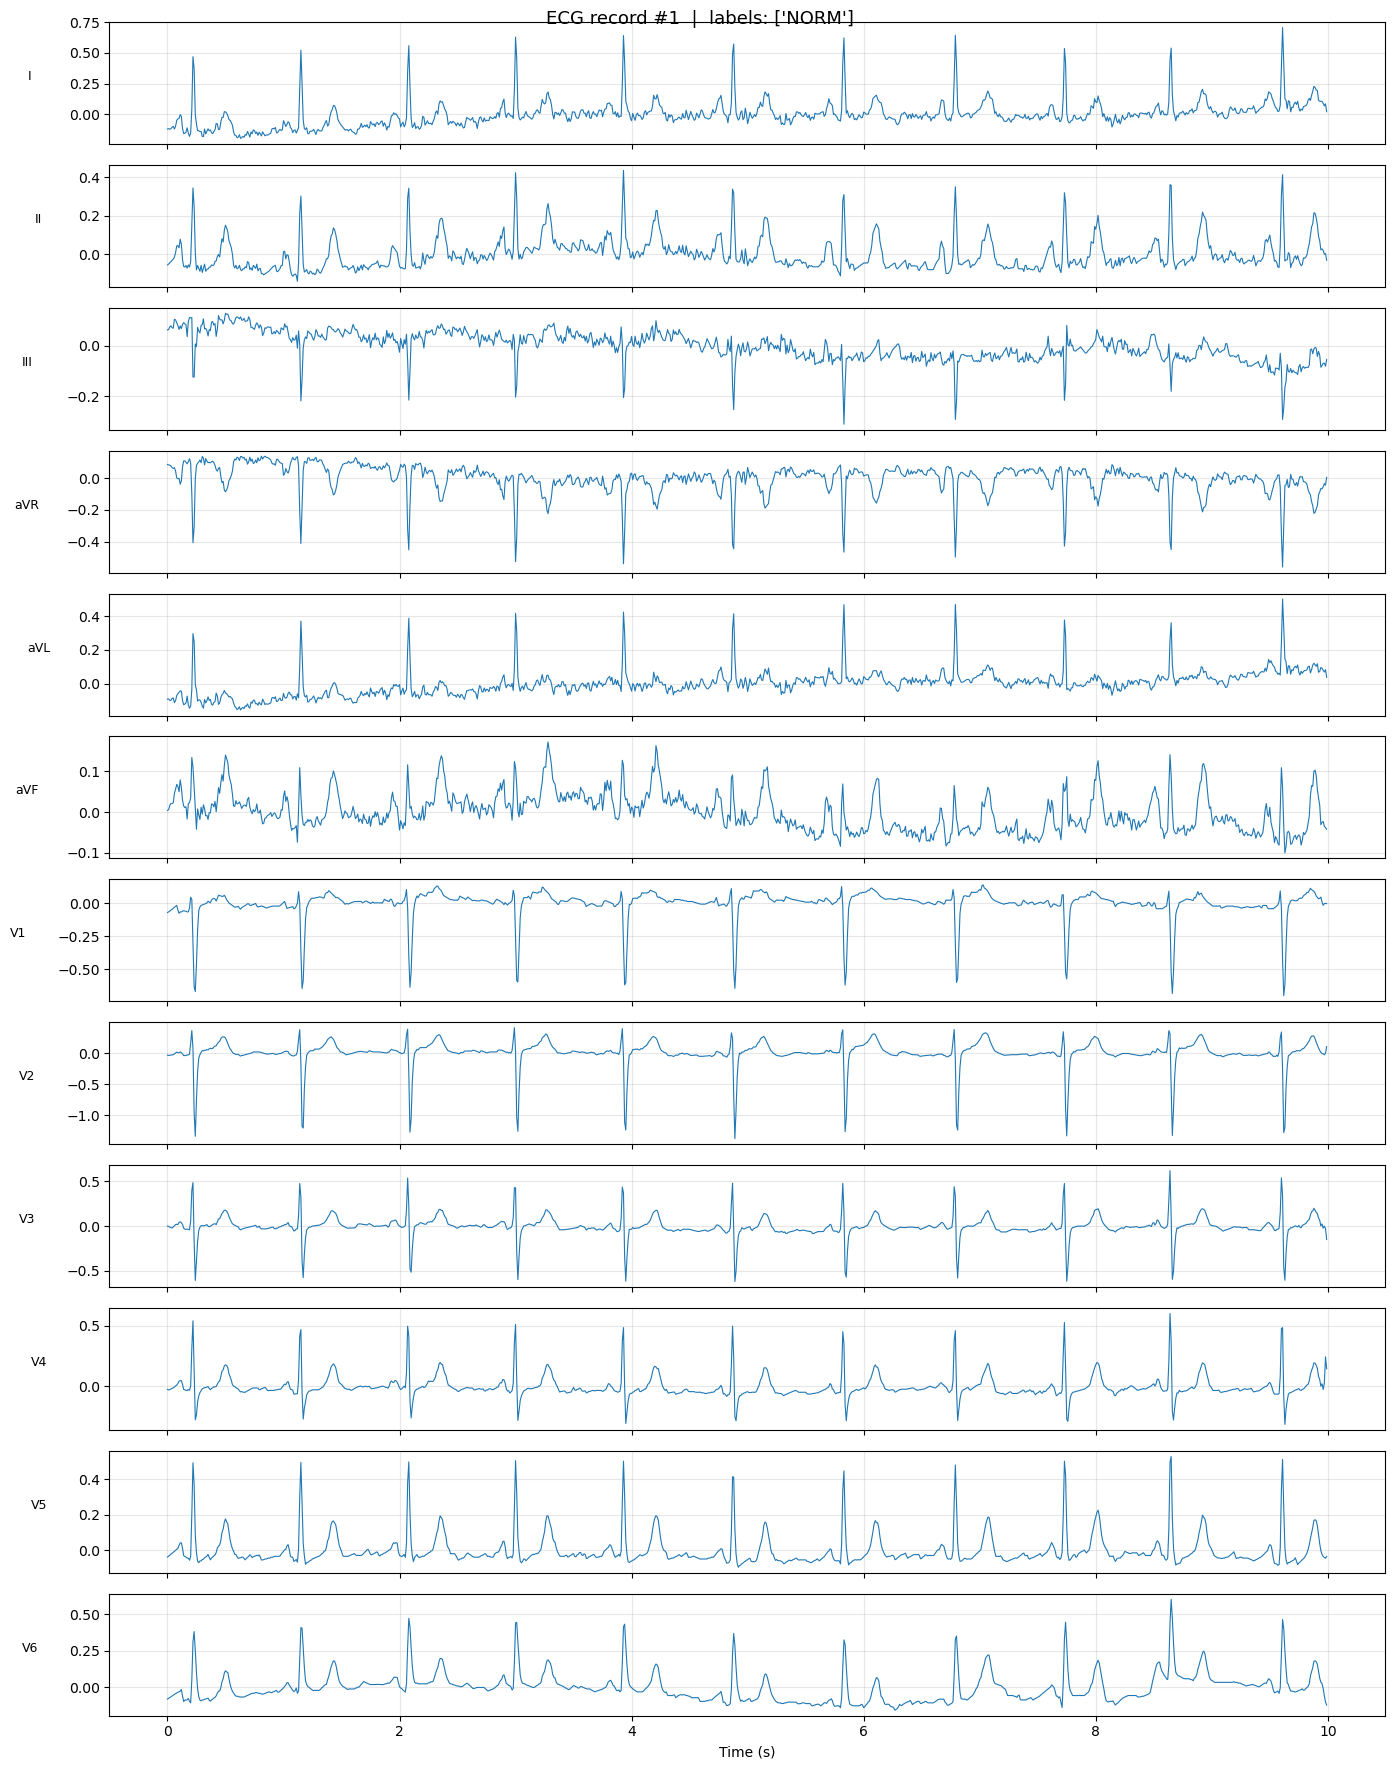

In [9]:
LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

sig = signals[0]
t = np.arange(sig.shape[0]) / SAMPLING_RATE

fig, axes = plt.subplots(12, 1, figsize=(14, 18), sharex=True)
fig.suptitle(f"ECG record #{df.index[0]}  |  labels: {df.iloc[0]['superclass']}", fontsize=13)
for i, ax in enumerate(axes):
    ax.plot(t, sig[:, i], lw=0.8)
    ax.set_ylabel(LEAD_NAMES[i], rotation=0, labelpad=28, fontsize=9)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 5 · Confirm the standard train / val / test split

The dataset ships with `strat_fold` (1–10):
- Folds **1–8** → train
- Fold **9** → validation
- Fold **10** → test

This is what makes results comparable to the published benchmark — never invent your own split.

In [10]:
train_df = df[df["strat_fold"] <= 8]
val_df   = df[df["strat_fold"] == 9]
test_df  = df[df["strat_fold"] == 10]

print(f"Train  (folds 1-8): {len(train_df):>6,}")
print(f"Val    (fold  9):   {len(val_df):>6,}")
print(f"Test   (fold 10):   {len(test_df):>6,}")
print(f"Total:              {len(df):>6,}")

assert len(train_df) + len(val_df) + len(test_df) == len(df)
print("\nSplit verified — no overlap, full coverage.")

Train  (folds 1-8): 17,418
Val    (fold  9):    2,183
Test   (fold 10):    2,198
Total:              21,799

Split verified — no overlap, full coverage.
